**2주차 복습과제**

📍Attention Is All You Need (Transformer)

교재 :  <(파이토치 트랜스포머를 활용한) 자연어 처리와 컴퓨터 비전 심층학습>

범위 :  7. 트랜스포머 (p.357 ~ 387)

###위치 인코딩

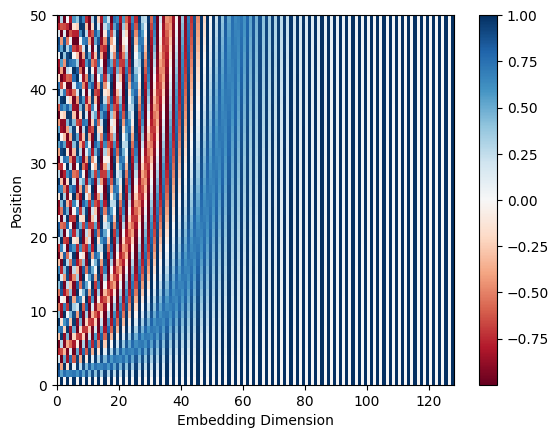

In [1]:
#위치 인코딩
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1): #입력 임베딩 차원과 최대 시퀀스를 입력받음
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position= torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2]= torch.sin(position * div_term) #입력 시퀀스의 위치마다 sin과 cos 함수로 위치 인코딩을 계산
        pe[:, 0, 1::2]= torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)

encoding = PositionalEncoding(d_model=128, max_len=50)

plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap="RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim((0,128))
plt.ylabel("Position")
plt.colorbar()
plt.show()

###모델 실습: 트랜스포머 모델을 활용한 영어-독일어 번역 모델

- 파이토치에서 제공하는 트랜스포머 모델을 활용해 영어-독일어 번역 모델 구성

- Nulti30k 데이터세트 사용
    - 자연어 처리를 위한 대규모 다국어 데이터세트
    - 영어-독일어 병렬 말뭉치(Parallel corpus)로 약 30,000개의 데이터 제공

In [ ]:
#토치 데이터 및 토치 텍스트 라이브러리 설치
!pip install torchdata torchtext portalocker

- 토치 데이터 라이브러리
    - 대규모 데이터세트를 다루기 쉽게 데이터를 불러오고 변환 및 배치하는 API 제공
- 토치 텍스트 라이브러리
    - 파이토치를 위한 텍스트 처리 라이브러리
    - 다양한 언어 모델링 작업에 대해 사전 처리 및 데이터세트 관리를 단순화하기 위한 다양한 도구와 기능 제공
- **포르타락커(portalocker)** 라이브러리
    - 파이썬에서 파일 락을 관리하기 위한 라이브러리
    - 파일 락을 사용해 여러 프로세스 간에 동시에 파일을 수정하거나 읽는 것을 방지
    - `Multi30k` 데이터세트 다운 및 압축 해제 과정에서 내부적으로 사용

In [ ]:
!pip install torch==2.3.1+cu121 \
              torchtext==0.18.0 \
              torchdata==0.7.1 \
              --extra-index-url https://download.pytorch.org/whl/cu121

In [ ]:
!pip install portalocker

In [2]:
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 71.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 116.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import torch, torchtext, torchdata
from torch import nn
import portalocker

In [2]:
#데이터세트 다운로드 및 전처리
from torchtext.datasets import Multi30k
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

def generate_tokens(text_iter, language):
    language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}

    for text in text_iter:
        yield token_transform[language](text[language_index[language]])

SRC_LANGUAGE = "de"
TGT_LANGUAGE = "en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols =["<unk>", "<pad>", "<bos>", "<eos>"]

#독일어 말뭉치와 영어 말뭉치에 대해 각각 토크나이저와 어휘 사전 생성
token_transform = {
    SRC_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm"), #사용자가 지정한 토크나이저를 가져오는 유틸리티 함수
    TGT_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm"),
}
print("Token Transform:")
print(token_transform)

vocab_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    train_iter = Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    vocab_transform[language] = build_vocab_from_iterator( #생성된 토큰을 이용해 단어 집합 생성
        generate_tokens(train_iter, language),
        min_freq=1,
        specials=special_symbols, #특수 토큰 지정
        special_first=True,
    )
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language].set_default_index(UNK_IDX) #인덱스의 기본값을 설정 -> <unk>의 인덱스 할당

print("Vocab Transform:")
print(vocab_transform)

/usr/local/lib/python3.12/dist-packages/torchtext/datasets/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext i

Token Transform:
{'de': functools.partial(<function _spacy_tokenize at 0x7f870a719760>, spacy=<spacy.lang.de.German object at 0x7f87061ebc80>), 'en': functools.partial(<function _spacy_tokenize at 0x7f870a719760>, spacy=<spacy.lang.en.English object at 0x7f87021594c0>)}
Vocab Transform:
{'de': Vocab(), 'en': Vocab()}


In [3]:
#트랜스포머 모델 구성
import math
import torch
from torch import nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position= torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2)*(-math.log(10000.0) /d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)

class Seq2SeqTransformer(nn.Module): #소스와 타깃 데이터의 어휘 사전 크기를 입력받아 트랜스포머 임베딩 크기로 변환
    def __init__(
        self,
        num_encoder_layers,
        num_decoder_layers,
        emb_size,
        max_len,
        nhead,
        src_vocab_size,
        tgt_vocab_size,
        dim_feedforward,
        dropout=0.1,
    ):
        super().__init__()
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(
            d_model=emb_size, max_len=max_len, dropout=dropout
        )
        self.transformer = nn. Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(
        self,
        src,
        trg,
        src_mask,
        tgt_mask,
        src_padding_mask,
        tgt_padding_mask,
        memory_key_padding_mask,
    ):
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        outs = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        return self.generator(outs) #트랜스포머 디코더 블록에서 산출되는 벡터를 선형 변환해 어휘 사전에 대한 로짓 생성

    def encode(self, src, src_mask):
        return self.transformer.encoder(
            self.positional_encoding(self.src_tok_emb(src)), src_mask
        )
    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(
            self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
    )

In [4]:
#트랜스포머 클래스
transformer = torch.nn.Transformer(
    d_model=512, #입출력 차원의 크기 정의
    nhead=8, #멀티 헤드 어텐션의 헤드 개수
    num_encoder_layers=6, #인코더, 디코더 계층 수
    num_decoder_layers=6,
    dim_feedforward=2048, #순방향 신경망의 은닉층 크기
    dropout=0.1,
    activation=torch.nn.functional.relu,
    layer_norm_eps=1e-05, #곝층 정규화 수행 시 분모에 더해지는 입실론 값
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [ ]:
#트랜스포머 순방향 메서드
output = transformer.forward(
    src,
    tgt,
    src_mask=None,
    tgt_mask=None,
    memory_mask=None,
    src_key_padding_mask=None,
    tgt_key_padding_mask=None,
    memory_key_padding_mask=None,
)

- **소스(`src`), 타깃(`tgt`)**
    - 인코더와 디코더에 대한 시퀀스
    - [ 소스(타깃) 시퀀스 길이, 배치 크기, 임베딩 차원 ] 형태의 데이터 입력
- **소스 마스크(`src_mask`), 타깃 마스크(`tgt_mask`)**
    - 소스와 타깃 시퀀스의 마스크
    - [ 소스(타깃) 시퀀스 길이, 시퀀스 길이 ] 형태의 데이터 입력
    - 마스크의 값이 0이라면 해당 위치에서는 모든 입력 단어가 동일한 가중치 갖고 어텐션이 수행, 1이라면 모든 입력 단어의 가중치가 0으로 설정돼 어텐션 연산 수행 X
    - -inf라면 해당 위치에서는 어텐션 연산 결과에 0으로 가중치가 부여돼 마스킹된 위치의 정보를 모델이 무시하게 만듦
    - +inf라면 모든 입력 단어에 무한대의 가중치가 부여돼 어텐션 연산 결과가 해당 위치에 대한 정보만으로 구성됨
        - 일반적으로 +inf는 적용 X, 어떤 특정 단어나 위치에 대해 모델이 특별한 관심 가지도록 할 때만 사용
- **메모리 마스크(`memory_mask`)**
    - 인코더 출력의 마스크
    - [ 타깃 시퀀스 길이, 소스 시퀀스 길이 ]의 형태
    - 메모리 마스크의 값이 0인 위치에서는 어텐션 연산이 수행 X
- **소스, 타깃, 메모리 키 패딩 마스크(`key_padding_mask`)**
    - 소스, 타깃, 메모리 시퀀스에 대한 패딩 마스크 의미
    - [ 배치 크기, 소스(타깃) 시퀀스 길이 ] 형태의 데이터 입력
    - 메모리 키 패딩 마스크는 소스 키 패딩 마스크와 동일한 형태의 데이터 입력
    - 키 패딩 마스크
        - 입력 시퀀스에서 패딩 토큰이 위치한 부분 가리키는 이진 마스크
        - 패딩 토큰이 실제 의미를 가지지 않는 것으로 간주되어 해당 위치의 어텐션 연산 결과에 대한 가중치 0으로 만듦
- 순방향 메서드는 인스턴스의 설정과 입력 시퀀스를 통해 타깃 시퀀스의 임베딩 텐서를 반환
    - [ 타깃 시퀀스 길이, 배치 크기, 임베딩 차원 ] 반환
- 현재 클래스에서는 어휘 사전에 대한 로짓을 생성 → 임베딩 차원이 타깃 데이터의 어휘 사전 크기로 변경됨

In [5]:
#트랜스포머 모델 구조
from torch import optim

BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward=512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("L", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("| L", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("| | L", sssub_name)

src_tok_emb
L embedding
tgt_tok_emb
L embedding
positional_encoding
L dropout
transformer
L encoder
| L layers
| | L 0
| | L 1
| | L 2
| L norm
L decoder
| L layers
| | L 0
| | L 1
| | L 2
| L norm
generator


- `Seq2SeqTransformer` 클래스
    - 입력 임베딩(`src_tok_emb`, `tgt_tok_emb`), 위치 인코딩(`positional_encoding`), 트랜스포머 블록(`transformer`), 로짓 생성(`generator`)으로 구성
    - 출력 결과에서 확인할 수 있듯 인코더와 디코더가 각각 세 개(0, 1, 2)의 계층으로 구성
        - 앞선 그림 7.2의 구조에서 인코더와 디코더가 세 번 반복되고, 로짓 생성이 추가된 구조
- 손실 함수는 교차 엔트로피 함수 적용
    - 무시되는 색인(`ignore_index`) 값을 패딩 토큰(`PAD_IDX`)을 할당해 모델이 학습하는 동안 무시해야 할 클래스 레이블 지정
    - 패딩 토큰은 모델 학습에 사용되지 않으므로 해당 토큰에 대한 레이블을 무시하고 모델이 해당 클래스를 학습하지 않게 함
        
        → 이 클래스에 대한 손실은 계산 X, 모델이 해당 클래스 예측하더라도 올바른 예측으로 간주 X

In [16]:
!rm -rf /root/.cache/torch/text/datasets/Multi30k

In [17]:
#배치 데이터 생성
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

def input_transform(token_ids):
    return torch.cat(
        (torch.tensor([BOS_IDX]), torch.tensor(token_ids), torch.tensor([EOS_IDX]))
)

def collator(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))

    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch

text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language], vocab_transform[language], input_transform
    )

data_iter = Multi30k(split="valid", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))

#출력용 iterator
data_iter_for_print = Multi30k(split="valid", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))

dataloader = DataLoader(
    data_iter,
    batch_size=BATCH_SIZE,
    collate_fn=collator,
    num_workers=0
)

# DataLoader에서 배치 가져오기
dataloader_iter = iter(dataloader)
source_tensor, target_tensor = next(dataloader_iter)

print("(source, target):")
print(next(iter(data_iter_for_print)))

print("source_batch:", source_tensor.shape)
print(source_tensor)

print("target_batch:", target_tensor.shape)
print(target_tensor)

(source, target):
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')
source_batch: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  14,    5,    5,  ...,    5,   21,    5],
        [  38,   12,   35,  ...,   12, 1750,   69],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])
target_batch: torch.Size([30, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [   6,    6,    6,  ...,  250,   19,    6],
        [  39,   12,   35,  ...,   12, 3254,   61],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


/usr/local/lib/python3.12/dist-packages/torchdata/datapipes/iter/util/cacheholder.py:434: UserWarning: Attempt to mark /root/.cache/torch/text/datasets/Multi30k/val.en.promise.46c2af81-2d5b-4f36-9d4f-0910d49868af promise (base of file /root/.cache/torch/text/datasets/Multi30k/val.en) as fulfilled failed. Potentially missmatching filename functions of on_disk_cache and end_cache.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchdata/datapipes/iter/util/cacheholder.py:434: UserWarning: Attempt to mark /root/.cache/torch/text/datasets/Multi30k/val.de.promise.763058e8-b44a-4f9e-8e6a-e46b627eaf31 promise (base of file /root/.cache/torch/text/datasets/Multi30k/val.de) as fulfilled failed. Potentially missmatching filename functions of on_disk_cache and end_cache.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchdata/datapipes/iter/util/cacheholder.py:434: UserWarning: Attempt to mark /root/.cache/torch/text/datasets/Multi30k/validation.tar.gz.promise.b9a6f06b-dde0-4

- `sequential_transforms` 함수
    - 여러 개의 전처리 함수를 인자로 받아 이를 차례로 적용하는 함수를 반환하는 함수
        
        → 예제에서는 세 종류의 전처리 수행
        
        - 첫 번째 매개변수: `token_transform`을 적용해 문장을 토큰화
        - 두 번째: `vocab_transform`을 적용해 각 토큰을 인덱스화
        - 마지막: `input_transform` 함수 - 인덱스화된 토큰에 문장의 시작 `BOS_IDX(2)`와 끝 `EOS_IDX(3)`을 알리는 특수 토큰을 할당
- `data_iter` 변수에 (독일어, 영어) 형태로 구성된 `Multi30k` 텍스트 데이터세트 불러옴
    - 이 데이터세트를 데이터로더에 적용, 집합 함수로 `collator` 함수 적용
    - `collator` 함수
        - 배치 단위로 데이터를 처리
        - `rstrip("\n")` 함수로 문자열의 끝에 있는 개행 문자 (`\n`)를 제거
        - `text_transform` 변수에 저장된 `sequential_transforms` 함수를 적용
        - 이후 패딩 시퀀스(`pad_sequence`) 함수를 사용해 소스와 타깃 시퀀스를 패딩
            - 패딩 시퀀스 함수는 동일한 길이를 가지도록 시퀀스의 뒤족에 `PAD_IDX(1)`로 채워진 패딩 토큰을 추가
- 이 데이터로더는 (패딩이 적용된 소스, 패딩이 적용된 타깃) 튜플을 반환
    - 출력되는 배치 데이터 차원은 [ 소스(타킷) 시퀀스 길이, 배치 크기 ]를 의미

In [18]:
#어텐션 마스크 생성
def generate_square_subsequent_mask(s):
    mask = (torch.triu(torch.ones((s,s), device=DEVICE)) == 1).transpose(0,1)
    mask = (
        mask.float()
        .masked_fill(mask == 0,float("-inf"))
        .masked_fill(mask == 1, float(0.0))
    )
    return mask

def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask=(tgt == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input
)

print("source_mask:", source_mask.shape)
print(source_mask)
print("target_mask:", target_mask.shape)
print(target_mask)
print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)

source_mask: torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:0')
target_mask: torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf,

- 트랜스포머 모델에서 사용되는 마스크를 생성하는 함수, 두 시퀀스의 패딩 마스크를 생성하는 함수로 구성됨
- `generate_square_subsequent_mask`: 마스크를 생성하는 함수
    - 입력으로 정수 `s`를 받아 `sxs` 크기의 마스크를 생성
    - `torch.ones`함수를 사용해 1로 채워진 행렬을 만든 후 `torch.triu` 함수를 적용해 상삼각행렬 생성
    - `transpose` 함수 사용하여 행렬을 전치
    - 마스크 텐서에서 0인 값은 -inf로, 1인 값은 0.0으로 채워 어텐션 연산에 적용
        - 0.0은 셀프 어텐션에 참조되는 시퀀스 가리킴
        - -inf 값은 셀프 어텐션 계산 과정에서 어텐션 스코어가 0에 수렴하기 때문에 해당 타깃 입력 시퀀스를 제외시키는 역할 함
- `create_mask` : 패딩 마스크를 행성하는 함수
    - 시퀀스를 입력받아 길이를 계산하고 마스크 생성 함수로 타킷 시퀀스의 마스크를 생성
    - 소스 마스크 - 소스 시퀀스 길이의 크기로 채워진 행렬 생성, 패딩 마스크 - 각 시퀀스에 대해 패딩 토큰의 위치를 찾고 `transpose` 함수로 전치
    - 패딩 마스크 생성 전에 타깃 데이터의 입력값(`target_input`)과 출력값(`target_out`)은 토큰 순서를 한 칸 시프트하여 이전 토큰들이 주어졌을 때 다음 토큰을 예측하게 함
- 패딩 마스크 생성 함수로 소스 시퀀스 입력값(`source_tensor`)과 타깃 시퀀스 입력값(`target_input`)을 전달해 4개의 텐서 생성
    - `source_mask`
        - 셀프 어텐션 과정에서 참조되는 소스 데이터의 시퀀스 범위
        - `False`인 위치는 셀프 어텐션에 참조되는 토큰, `True`인 위치는 제외되는 토큰
        - 출력 결과 확인해 보면 소스 데이터는 모든 시퀀스를 대상으로 셀프 어텐션이 수행됨
    - `target_mask`
        - [쿼리 시퀀스 길이, 키 시퀀스 길이]의 형태로 구성
        - i번째 쿼리 벡터는 i+1 이상의 키 벡터에 대해 어텐션 연산을 수행할 수 없게 됨
            
            ⇒ 모델이 현재 예측하고자 하는 위치 이전의 토큰들만 참고하게 제한 → 모델이 미래 시점의 정보를 사용하지 않게 해 현재 시점에 영향 미치지 않게 함
            
    - `source_padding_mask`, `target_padding_mask`
        - 소스(타깃) 배치 데이터에서 텍스트 토큰이 존재하는지 여부 나타냄
        - `False`인 경우 해당 토큰 인덱스가 존재, `True`인 경우 해당 토큰 인덱스가 패딩 토큰으로 채워져 있음

In [19]:
#모델 학습 및 평가
def run(model, optimizer, criterion, split):
    model.train() if split == "train" else model.eval()
    data_iter = Multi30k(split=split, language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

    losses = 0
    for source_batch, target_batch in dataloader:
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        target_input = target_batch[ :- 1, :]
        target_output = target_batch[1:, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
        source_batch, target_input
        )

        logits = model(
            src=source_batch,
            trg=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )

        optimizer.zero_grad()
        loss = criterion(logits.reshape(-1, logits.shape[-1]), target_output.reshape(-1))
        if split == "train":
            loss.backward()
            optimizer.step()
        losses += loss.item()

    return losses / len(list(dataloader))

for epoch in range(5):
    train_loss = run(model, optimizer, criterion, "train")
    val_loss = run(model, optimizer, criterion, "valid")
    print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch: 1, Train loss: 4.682, Val loss: 3.922
Epoch: 2, Train loss: 3.703, Val loss: 3.618
Epoch: 3, Train loss: 3.470, Val loss: 3.592
Epoch: 4, Train loss: 3.340, Val loss: 3.572
Epoch: 5, Train loss: 3.220, Val loss: 3.510


- `run` 함수
    - 모델 학습 및 평가를 위한 함수
    - 소스와 타깃 데이터를 입력받아 `collator`로 문장들을 토큰화, 인덱스로 변환
- `create_mask` 함수
    - 트랜스포머 모델에 필요한 입력 패딩 마스크(`src_padding_mask`, `tgt_padding_mask`)와 어텐션 마스크(`src_mask`, `tgt_mask`)를 생성
    - 결괏값들은 타깃 시퀀스의 i번째까지 토큰이 주어졌을 때 i+1번째 토큰을 예측하는 데 활용됨

In [20]:
#트랜스포머 모델 번역 결과
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)

    memory = model.encode(source_tensor, source_mask)
    ys=torch.ones(1,1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask= target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask)
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat(
            [ys, torch.ones(1,1).type_as(source_tensor.data).fill_(next_word)], dim=0
        )
        if next_word == EOS_IDX:
            break
    return ys

def translate(model, source_sentence):
    model.eval()
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens = source_tensor.shape[0]
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX
    ).flatten()
    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))[1:-1]
    return " ".join(output)

output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu .")
output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")
print(output_oov)
print(output)

A group of people are standing outside of a building .
A group of people are standing outside of a building .


- 모델 번역 방식은 **그리드 디코딩(Greedy decoding)** 방식으로 번역 결과를 출력
    - 디코더 네트워크가 생성한 확률 분포에서 가장 높은 확률을 가지는 단어 선택하는 방법
    - 현재 시점에서 가장 확률이 높은 단어를 선택해 디코딩 진행
- 모델 추론 방식은 디코더에 참조되는 마지막 인코더 트랜스포머 블록의 벡터(`memory`), 타깃 데이터의 입력 텐서(`ys`), 타깃 마스크(`target_mask`)를 사용
    - `memory` 텐서를 생성하려면 소스 문장을 토큰 인덱스로 표현한 `source_tensor`를 생성하고, `source_mask`는 소스 문장에서 모든 토큰이 어텐션 될 수 있게 0 값으로 설정
    - `model.encode` 메서드에 `source_tensor`와 `source_mask`를 입력으로 넣어 소스 문장에 대한 인코딩을 수행해 마지막 인코더 트랜스포머 블록의 벡터 추출
    - `model.decode` 메서드에서 생성된 out은 [ 토큰 개수, 배치 크기, 확률 ]의 형태
        - 이 값을 `transpose` 함수 이용하여 [배치 크기, 토큰 개수, 확률] 형태로 변환 후 텐서를 슬라이싱해 [ 배치 크기, 확률 ] 형태로 만듦
        - 이후 어휘 사전에서 가장 확률이 높은 토큰 인덱스 찾음
    
    ⇒ 이 과정을 `max_len` 이전이거나 `EOS_IDX` 예측할 때까지 반복, 최종적으로 예측된 토큰 시퀀스를 반환
    
- `max_len`은 `num_tokens + 5` 로 구성
    - `num_tokens` 는 소스 문장의 토큰 개수 의미
    - 생성된 문장의 길이가 소스 문장 길이보다 약간 더 길어지는 경우 많기 때문에 5를 더함
- `greedy_decode` 함수
    - 현재까지 예측된 토큰들 이용해 가장 높은 확률 가지는 단어 선택하여 다음 토큰으로 예측
    - 예측된 토큰 인덱스를 어휘 사전의 `lookup_tokens` 함수를 통해 텍스트로 변환
    - 후처리로 `<bos>` 와 `<eos>` 토큰은 슬라이싱(`[1:-1]`)으로 제거
    - 처리된 텍스트를 공백으로 구분해 하나의 문장으로 반든 후 반환
- 변역 결과를 보면 모델이 입력 문장의 의미 정확히 파악 못하고 잘못된 번역 결과 도출
    - 이글루Iglu는 OOV 데이터로 학습하지 않았기 때문에 번역 결과가 부정확할 수 있음
    - 건물Gebäude을 입력해 번역하면 모델이 입력 문장의 의미 올바르게 파악
    - 출력 결과 보면 OOV인 Iglu도 ‘building’으로 번역했기 때문에 Gebäude를 인식해 ‘building’으로 번역한 것이 아닌 ‘large’ 다음에 자연스럽게 ‘building’이 따라올 것이라는 걸 학습했을 가능성
    
    ⇒ 더 정확한 번역 위해 더 많은 학습 데이터 사용하거나 모델의 구조 또는 하이퍼파라미터 등을 번경해 모델의 성능을 지속적으로 모니터링, 개선